In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

fg = pd.read_csv('fear_greed_index.csv')
histo_d = pd.read_csv('historical_data.csv')

print('Fear/Greed data shape:', fg.shape)
print('Historical trade data shape:', histo_d.shape)

fg.head()

Fear/Greed data shape: (2644, 4)
Historical trade data shape: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [2]:
histo_d.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
# Check for missing values in both datasets
print('Missing values in fear_greed data:')
print(fg.isnull().sum())
print()
print('Missing values in historical trade data:')
print(histo_d.isnull().sum())

Missing values in fear_greed data:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in historical trade data:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [4]:
# Convert Timestamp IST to a proper datetime, then extract just the date part
histo_d['date'] = pd.to_datetime(histo_d['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date

# Make sure fear/greed date column is also a proper date type
fg['date'] = pd.to_datetime(fg['date']).dt.date

print(histo_d['date'].head())
print(fg['date'].head())

0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: date, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [5]:
merged = histo_d.merge(fg[['date', 'classification']], on='date', how='left')

print('Merged shape:', merged.shape)
print('Rows with missing sentiment after merge:', merged['classification'].isnull().sum())

# Drop the few trades where we couldn't find a matching sentiment label
merged = merged.dropna(subset=['classification'])

merged[['Account', 'Coin', 'date', 'classification', 'Closed PnL']].head()

Merged shape: (211224, 18)
Rows with missing sentiment after merge: 6


,Account,Coin,date,classification,Closed PnL
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,0.0


classification
Extreme Fear     34.537862
Fear             54.290400
Neutral          34.307718
Greed            42.743559
Extreme Greed    67.892861
Name: Closed PnL, dtype: float64


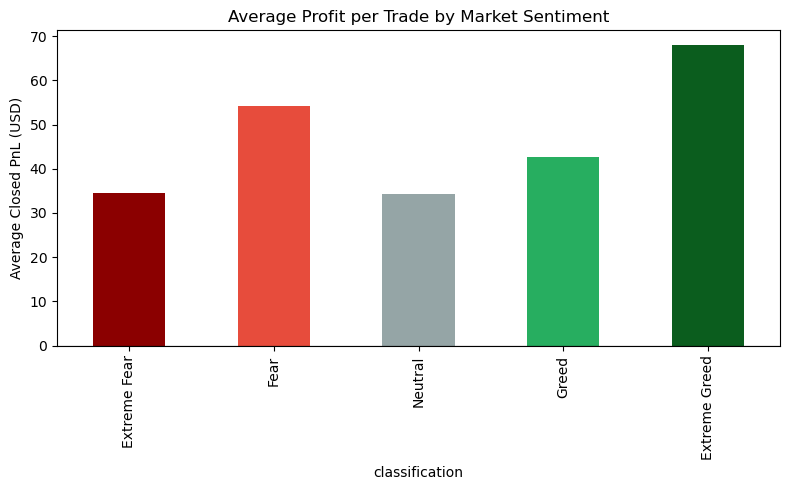

In [6]:
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

avg_pnl = merged.groupby('classification')['Closed PnL'].mean().reindex(order)
print(avg_pnl)

avg_pnl.plot(kind='bar', color=['#8B0000','#E74C3C','#95A5A6','#27AE60','#0B5D1E'], figsize=(8,5))
plt.title('Average Profit per Trade by Market Sentiment')
plt.ylabel('Average Closed PnL (USD)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

classification
Extreme Fear     76.215645
Fear             87.288647
Neutral          82.388898
Greed            76.890690
Extreme Greed    89.167026
dtype: float64


/var/folders/dw/vjmygwts5fq6v14dnflz23dm0000gn/T/ipykernel_1857/3149610285.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rate = closed_trades.groupby('classification').apply(lambda x: (x['Closed PnL'] > 0).mean() * 100).reindex(order)


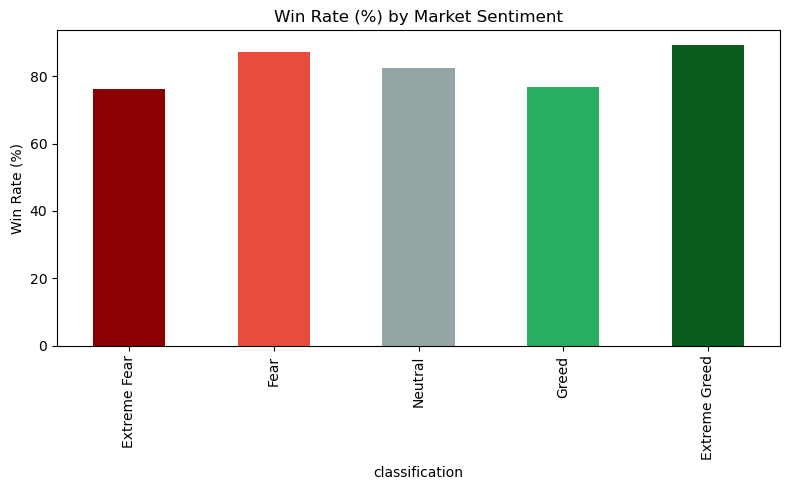

In [7]:
closed_trades = merged[merged['Closed PnL'] != 0]

win_rate = closed_trades.groupby('classification').apply(lambda x: (x['Closed PnL'] > 0).mean() * 100).reindex(order)
print(win_rate)

win_rate.plot(kind='bar', color=['#8B0000','#E74C3C','#95A5A6','#27AE60','#0B5D1E'], figsize=(8,5))
plt.title('Win Rate (%) by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.tight_layout()
plt.show()

classification
Extreme Fear     114.484261
Fear             483.324790
Neutral          180.242063
Greed            288.582495
Extreme Greed    124.465165
Name: Size USD, dtype: float64


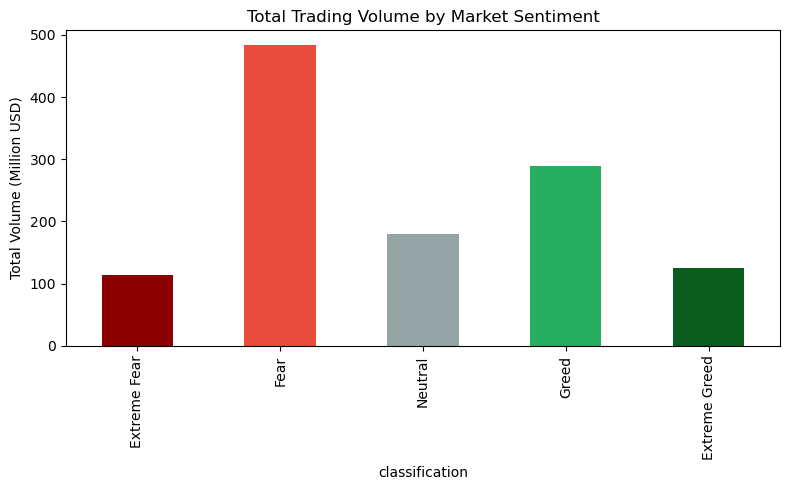

In [8]:
volume = merged.groupby('classification')['Size USD'].sum().reindex(order) / 1e6
print(volume)

volume.plot(kind='bar', color=['#8B0000','#E74C3C','#95A5A6','#27AE60','#0B5D1E'], figsize=(8,5))
plt.title('Total Trading Volume by Market Sentiment')
plt.ylabel('Total Volume (Million USD)')
plt.tight_layout()
plt.show()

Side                  BUY       SELL
classification                      
Extreme Fear    51.098131  48.901869
Fear            48.951275  51.048725
Neutral         50.334342  49.665658
Greed           48.855933  51.144067
Extreme Greed   44.858972  55.141028


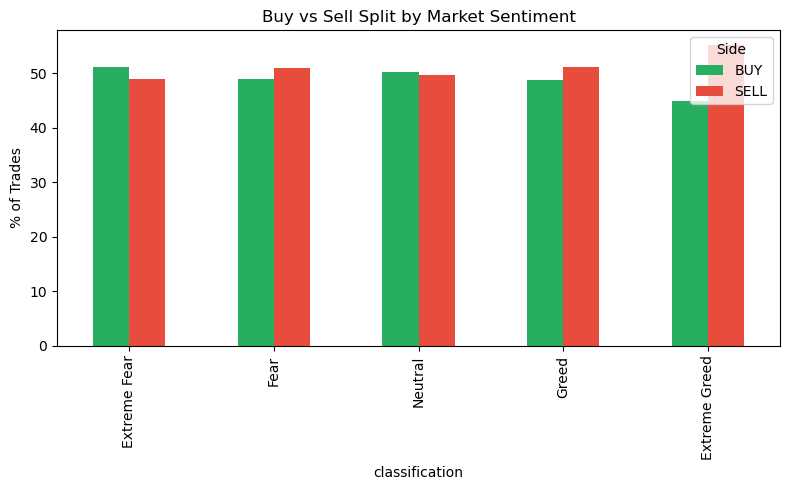

In [9]:
side_counts = merged.groupby(['classification', 'Side']).size().unstack().reindex(order)
side_pct = side_counts.div(side_counts.sum(axis=1), axis=0) * 100
print(side_pct)

side_pct.plot(kind='bar', figsize=(8,5), color=['#27AE60','#E74C3C'])
plt.title('Buy vs Sell Split by Market Sentiment')
plt.ylabel('% of Trades')
plt.tight_layout()
plt.show()